<a href="https://colab.research.google.com/github/michael-zhang0/A02-eda-and-visualization/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Sihan Michael Zhang

**Date:** 9/11/26

In [ ]:
# Your Phase 1 solution to the problem goes here.

# Q1 Uploaded as 'A02_Q1.HEIC' in the github repo

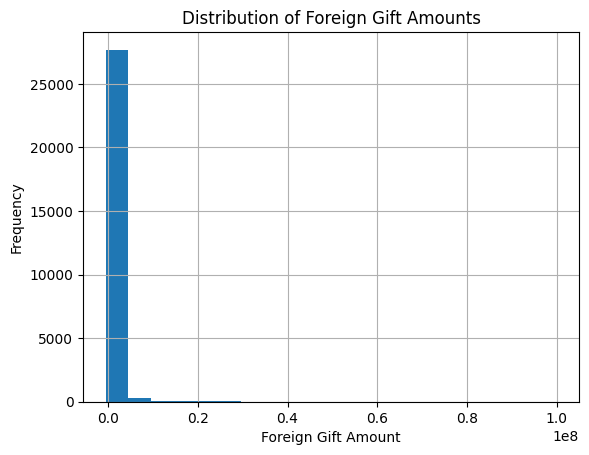

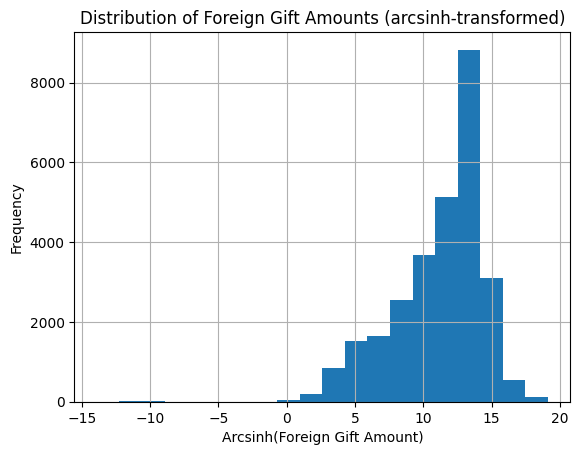

Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
dtype: int64
Gift Type
Contract         61.209737
Monetary Gift    38.751285
Real Estate       0.038978
dtype: float64


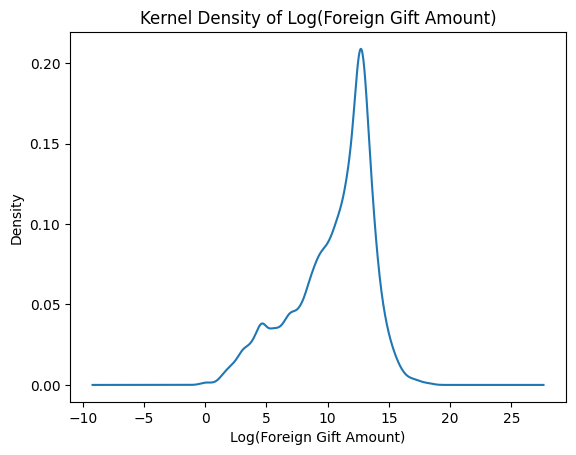

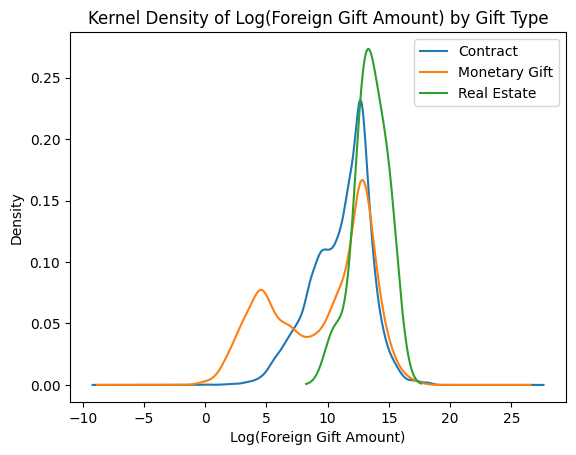

Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
dtype: int64
Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUSTRALIA                248409202
Name: Foreign Gift Amount, dtype: int64
[nan 'Confucius Institute 

,Foreign Gift Amount
Giftor Name,
Qatar Foundation,1166503744
Qatar Foundation/Qatar National Res,796197000
Qatar Foundation for Education,373945215
Anonymous,338793629
Saudi Arabian Cultural Mission,275221475
HCL,190000000
Church of Jesus Christ of LDS,185203715
Emirates Institute for Advanced Sc,170641244
QIC,148355497


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Q2.1
df = pd.read_csv('./data/ForeignGifts_edu.csv')

# Q2.2
# The untransformed graph for foreign gift amount is extremely right-skewed and
# basically unreadable, so I transformed it with arcsinh.

# Foreign gift amount has about ~28000 observations with a huge range, from
# small and negative amounts to extreme outliers near $100 million, which is why
# a transformation was needed for the graph. These outliers make distinguishing
# between a gift in the tens of thousands and in the lower millions impossible,
# which is why the transformation is needed. After applying arcsinh, we can see
# that there is a steady climb in frequency between arcinh values of 0-12, which
# is up to about $80000. The tallest bar is at around 12-13, which is about
# $80000 to $220000, which is a general estimation of what the mode might be.
# After the peak, there is a sharp drop-off to about 16, which is about $4.5
# million, and then a few values past that. There is also a few negative values
# at around -9 to -13, which may be a few negative gift amount outliers.

# Untransformed graph
ax = df["Foreign Gift Amount"].hist(bins=20)
ax.set_xlabel("Foreign Gift Amount")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Foreign Gift Amounts")
plt.show()
# Arcsinh transformed graph
df["foreign_gift_amount_arcsinh"] = np.arcsinh(df["Foreign Gift Amount"])
ax = df["foreign_gift_amount_arcsinh"].hist(bins=20)
ax.set_xlabel("Arcsinh(Foreign Gift Amount)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Foreign Gift Amounts (arcsinh-transformed)")
plt.show()

# Q2.3
# The gifts are 61.21% contract, 38.75% monetary gift, 0.04% real estate
#print(df["Gift Type"].value_counts())
#print(df["Gift Type"].value_counts(normalize=True)*100)
print(df.groupby("Gift Type").size())
print(df.groupby("Gift Type").size()/df.groupby("Gift Type").size().sum()*100)

# Q2.4
# Remove negative gift amounts because log must be positive

# For the single KDE plot, it has a tall peak around log value 12.5, with sharp
# incline and decline on either side. For the plot by gift type, monetary and
# contract peak at about the same log value, but monetary has another smaller
# peak around log value 5 and a valley at around 8. The peak from monetary at
# log value 5 explains the tiny peak on the overall KDE plot, as it increases
# from about 0 to 12.5 with the exception of that tiny peak at 5. It is also
# worth noting that the real estate KDE is very concentrated at high log values
# of about 11-16, with the peak at about 13-14, which is higher than contract
# and monetary.

# Single KDE plot
df_positive = df[df["Foreign Gift Amount"] > 0].copy()
df_positive["log_gift_amount"] = np.log(df_positive["Foreign Gift Amount"])
ax = df_positive["log_gift_amount"].plot(kind="kde")
ax.set_xlabel("Log(Foreign Gift Amount)")
ax.set_title("Kernel Density of Log(Foreign Gift Amount)")
plt.show()
# KDE plot by gift type
fig, ax = plt.subplots()
for gift_type, group in df_positive.groupby("Gift Type"):
    group["log_gift_amount"].plot(kind="kde", ax=ax, label=gift_type)
ax.set_xlabel("Log(Foreign Gift Amount)")
ax.set_title("Kernel Density of Log(Foreign Gift Amount) by Gift Type")
ax.legend()
plt.show()

# Q2.5
# Top 15 countries by number of gifts (descending): England, China, Canada,
# Japan, Switzerland, Saudi Arabia, France, Germany, Hong Kong, South Korea,
# Qatar, The Netherlands, Korea, India, Taiwan
# Top 15 countries by amount given (descending): Qatar, England, China, Saudi
# Arabia, Bermuda, Canada, Hong Kong, Japan, Switzerland, India, Germany, United
# Arab Emirates, France, Singapore, Australia
print(df.groupby("Country of Giftor").size().sort_values(ascending=False).head(15))
print(df.groupby("Country of Giftor")["Foreign Gift Amount"].sum().sort_values(ascending=False).head(15))

# Q2.6
# Top 10 giftors by amount (descending): Qatar Foundation, Qatar Foundation/
# Qatar National Res, Qatar Foundation for Education, Anonymous, Saudi Arabian
# Cultural Mission, HCL, Church of Jesus Christ of LDS, Emirates Institute for
# Advanced Sc, QIC, Anonymous #9
print(df.groupby("Giftor Name")["Foreign Gift Amount"].sum().sort_values(ascending=False).head(10))

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]